# Домашнее задание 3. Облачная инфраструктура

Студент: *Терещенкова Лилия Юльевна*, группа 501, 09/04/2026

Это задание выполняется в рамках модуля 3 «Инфраструктура как код, Ansible и Terraform».

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

In [1]:
%%capture
!sudo apt update
!sudo apt install -y ansible
%pip install ansible -qqq

### Задание 1. Равернуть инфраструктуру

Задача: конфигурация OpenTofu содержит опечатку. Исправьте ошибку, чтобы конфигурация проходила валидацию.


In [2]:
!curl --proto '=https' --tlsv1.2 -fsSL https://get.opentofu.org/install-opentofu.sh -o install-opentofu.sh
!chmod +x install-opentofu.sh
!./install-opentofu.sh --install-method deb
!rm -f install-opentofu.sh

OpenTofu Installer

Attempting installation via Debian repository...
Updating package list...
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]               
Hit:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease     
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,983 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to prov

In [3]:
!which opentofu

In [4]:
!tofu init

OpenTofu initialized in an empty directory!

The directory has no OpenTofu configuration files. You may begin working
with OpenTofu immediately by creating OpenTofu configuration files.


In [21]:
%%writefile main.tf
terraform {
  required_providers {
    null = {
      source = "hashicorp/null"
      version = ">= 3.0"
    }
  }
}

data "null_data_source" "example" {
  inputs = {
    location = "ru-1"
    disk = 18 * 1024
    type = "postgres"                # <- как нужно правильно оформить строковый литерал ?
  }
}

resource "null_resource" "example" {
  provisioner "local-exec" {
    command = "echo 'Создан требуемый ресурс'"
  }
}

Overwriting main.tf


In [22]:
!tofu show

No state.


### Исправление ошибок в конфигурации OpenTofu

1. Убедитесь, что OpenTofu установлен и доступен для выполнения команд.
2. Проверьте корректность конфигурационного файла.

Валидация успешна, если есть сообщение `Success! The configuration is valid, but there were some validation warnings as shown above`.



In [23]:
!export TOFU_LOG=DEBUG # Устанавливаем уровень логирования на DEBUG для OpenTofu
!tofu validate

╷
│ Warning: Deprecated
│ 
│   with data.null_data_source.example,
│   on main.tf line 10, in data "null_data_source" "example":
│   10: data "null_data_source" "example" {
│ 
│ The null_data_source was historically used to construct intermediate values to re-use elsewhere in configuration, the same can now be achieved using locals or the terraform_data resource type in Terraform 1.4 and later.
╵
Success! The configuration is valid, but there were some validation warnings as shown above.


Ansible поможет нам управлять инфраструктурой, а OpenTofu будет использоваться для описания и развертывания ресурсов.

In [24]:
%%writefile inventory.ini
[local]
localhost ansible_connection=local

Overwriting inventory.ini


In [25]:
%%writefile playbook.yaml
---
- name: Создаём инфраструктуру с OpenTofu
  hosts: local
  tasks:
    - name: Создать новый проект с OpenTofu
      command: tofu init

    - name: Посмотреть конфиг OpenTofu
      command: tofu show


Overwriting playbook.yaml


Выполним плейбук

In [26]:
!ansible-playbook -i inventory.ini playbook.yaml


PLAY [Создаём инфраструктуру с OpenTofu] ***************************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'localhost' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [localhost]

TASK [Создать новый проект с OpenTofu] *****************************************
changed: [localhost]

TASK [Посмотреть конфиг OpenTofu] **********************************************
changed: [localhost]

PLAY RECAP *********************************************************************
localhost                  : ok=3    changed=2    unreachable=0    failed=0    skipped=0    rescued=0    ignored=0   



### Использование логов и отладочных инструментов

Логи и отладочные инструменты помогают глубже понять, что происходит в процессе выполнения команд Ansible и OpenTofu. Используйте их для выявления и устранения проблем.

In [27]:
# Включение детализированных логов для Ansible
!ansible-playbook -i inventory.ini playbook.yaml -v # Запускаем плейбук с детализированными логами

No config file found; using defaults

PLAY [Создаём инфраструктуру с OpenTofu] ***************************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'localhost' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [localhost]

TASK [Создать новый проект с OpenTofu] *****************************************
changed: [localhost] => {"changed": true, "cmd": ["tofu", "init"], "delta": "0:00:00.270051", "end": "2026-04-09 14:23:50.156477", "msg": "", "rc": 0, "start": "2026-04-09 14:23:49.886426", "stderr": "", "stderr_lines": [], "stdout": "\n\u001b\u001bInitializing the backend...\u001b\n\n\u001b\u001bInitializing provider plugins...\u001b\n- Reusing previous version of hashicorp/n

## Задание 2. Описать инфраструктуру в декларативном формате

Задача: в конфигурации Ansible нет файла инвентаря. Нужно прописать файл инвентаря, чтобы плейбук выполнялся корректно.

In [28]:
%%writefile inventory.ini
[local]
localhost ansible_connection=local
[webservers]
localhost ansible_connection=local

Overwriting inventory.ini


In [29]:
%%writefile playbook.yaml
---
- name: Установка и запуск веб-сервера
  hosts: webservers
  become: yes
  tasks:
    - name: Установка Apache
      apt:
        name: apache2
        state: present
        update_cache: yes
    - name: Запуск и включение Apache
      service:
        name: apache2
        state: started
        enabled: yes

Overwriting playbook.yaml


### Исправление ошибок в плейбуке

1. Убедитесь, что Ansible установлен и доступен для выполнения команд.
2. Проверьте, что файл инвентаря и плейбук созданы корректно.
3. Запустите плейбук и исправьте ошибки, если они возникнут.

При корректном запуске в итоговой строке PLAY RECAP будет указано количество выполненных без ошибок этапов ok=3

In [30]:
!ansible-playbook -i inventory.ini playbook.yaml # Выполняем плейбук для установки и запуска Apache


PLAY [Установка и запуск веб-сервера] ******************************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'localhost' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [localhost]

TASK [Установка Apache] ********************************************************
changed: [localhost]

TASK [Запуск и включение Apache] ***********************************************
changed: [localhost]

PLAY RECAP *********************************************************************
localhost                  : ok=3    changed=2    unreachable=0    failed=0    skipped=0    rescued=0    ignored=0   



## Задание 3. Настроить ML/DS-стек, используя Ansible

Соберите типовой стек (как минимум pandas + numpy + scikit-learn + mlflow)

In [37]:
%%writefile playbook.yaml
---
- name: Настройка ML/DS-стек
  hosts: all
  become: yes
  tasks:
    - name: Обновить apt кэш
      apt:
        update_cache: yes

    - name: Установить Python3 и pip
      apt:
        name:
          - python3
          - python3-pip
        state: present

    - name: Установить pandas через pip
      pip:
        name: pandas
        state: present
        executable: pip3

    - name: Проверить установку pandas
      command: python3 -c "import pandas; print(pandas.__version__)"
      register: pandas_version
      changed_when: false

    - name: Вывести версию pandas
      debug:
        msg: "Установлен pandas версии: {{ pandas_version.stdout }}"

    - name: Установить numpy через pip
      pip:
        name: numpy
        state: present
        executable: pip3

    - name: Проверить установку numpy
      command: python3 -c "import numpy; print(numpy.__version__)"
      register: numpy_version
      changed_when: false

    - name: Вывести версию numpy
      debug:
        msg: "Установлен numpy версии: {{ numpy_version.stdout }}"

    - name: Установить scikit-learn через pip
      pip:
        name: scikit-learn
        state: present
        executable: pip3

    - name: Проверить установку scikit-learn
      command: python3 -c "import sklearn; print(sklearn.__version__)"
      register: sklearn_version
      changed_when: false

    - name: Вывести версию scikit-learn
      debug:
        msg: "Установлен scikit-learn версии: {{ sklearn_version.stdout }}"

    - name: Установить mlflow через pip
      pip:
        name: mlflow
        state: present
        executable: pip3

    - name: Проверить установку mlflow
      command: python3 -c "import mlflow; print(mlflow.__version__)"
      register: mlflow_version
      changed_when: false

    - name: Вывести версию mlflow
      debug:
        msg: "Установлен mlflow версии: {{ mlflow_version.stdout }}"


Overwriting playbook.yaml


In [38]:
!ansible-playbook -i inventory.ini playbook.yaml # Выполняем плейбук для установки и запуска Apache


PLAY [Настройка ML/DS-стек] ****************************************************

TASK [Gathering Facts] *********************************************************
[WARNING]: Host 'localhost' is using the discovered Python interpreter at '/usr/bin/python3.12', but future installation of another Python interpreter could cause a different interpreter to be discovered. See https://docs.ansible.com/ansible-core/2.20/reference_appendices/interpreter_discovery.html for more information.
ok: [localhost]

TASK [Обновить apt кэш] ********************************************************
ok: [localhost]

TASK [Установить Python3 и pip] ************************************************
ok: [localhost]

TASK [Установить pandas через pip] *********************************************
ok: [localhost]

TASK [Проверить установку pandas] **********************************************
ok: [localhost]

TASK [Вывести версию pandas] ***************************************************
ok: [localhost] => {
   

## Задание 4. Настроить ML/DS-стек, используя CloudInit

Соберите типовой стек (как минимум pandas + numpy + scikit-learn + mlflow) и проверьте конфигурацию на отсутствие ошибок


In [41]:
!apt-get update
!apt-get install -y cloud-init

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]               
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease     
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:7 https://packages.opentofu.org/opentofu/tofu/any any InRelease
Fetched 3,917 B in 1s (3,698 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.li

In [45]:
%%writefile cconf.yml
#cloud-config
package_update: true
packages:
  - python3
  - python3-pip
runcmd:
  - pip3 install pandas numpy scikit-learn mlflow


Overwriting cconf.yml


In [47]:
!cloud-init schema --config-file=cconf.yml --annotate

Valid schema cconf.yml


## Задание 5. Спроектировать ML-систему для обработки аудиоданных

**Писать код не нужно.**

Нужно выбрать архитектуру и составить схематическое описание  ML-системы с помощью библиотеки docker-compose-diagram, добавляя в каждый сервис depends_on.

Вводные данные от бизнеса: «Клиенты глэмпинга должны получать уведомление в Телеграм, когда утром запоет первый жаворонок» и пример аудиоданных.

Какие компоненты будут добавлены в такую систему и почему?

Рассуждения

пойдем с конца: 
- логирование и мониторинг системы (Grafana)
- бот Телеграма, на который будут подписаны пользователи
- демон запуска задач по расписанию (раз в минуту) - проверка наличия сообщений для пользователя, отправка
- redis для хранения сообщений
- сервис с python-скриптом, который инициирует отправку сообщений бота в redis
- сервис, который применяет обученную модель к аудиофайлу
- сервис для хранения обученных моделей
- валидация модели по метрикам
- сервис для обучения/переобучения модели
- облачный сервер (S3) для хранения аудиофайлов
- сервис загрузки в object storage + запись метаданных в БД
- приемник для записи аудиофайлов

In [48]:
!wget -q -O example.wav https://raw.githubusercontent.com/scikit-maad/scikit-maad/production/data/spinetail.wav
from IPython.display import Audio; Audio('example.wav')

In [17]:
%%capture
!sudo apt install graphviz
!pip install docker-compose-diagram

In [103]:
%%writefile docker-compose.yml
services:

  audio-ingest:
    container_name: audio_ingest
    labels:
      "docker_compose_diagram.cluster": "сбор и хранение информации"
      "docker_compose_diagram.icon": "diagrams.onprem.client.Client"
      "docker_compose_diagram.description": |
        прием аудиофайлов
        от устройств/источников

  storage-uploader:
    container_name: storage_uploader
    depends_on:
      - audio-ingest
      - s3-storage
      - metadata-db
    labels:
      "docker_compose_diagram.cluster": "сбор и хранение информации"
      "docker_compose_diagram.icon": "diagrams.onprem.etl.Embulk"
      "docker_compose_diagram.description": |
        загрузка аудио в object storage
        и запись метаданных

  s3-storage:
    container_name: s3_storage
    labels:
      "docker_compose_diagram.cluster": "сбор и хранение информации"
      "docker_compose_diagram.icon": "diagrams.aws.storage.S3"
      "docker_compose_diagram.description": |
        хранение сырых
        аудиофайлов

  metadata-db:
    container_name: metadata_db
    labels:
      "docker_compose_diagram.cluster": "сбор и хранение информации"
      "docker_compose_diagram.icon": "diagrams.onprem.database.PostgreSQL"
      "docker_compose_diagram.description": |
        хранение метаданных
        и ссылок на аудио

  model-training:
    container_name: model_training
    depends_on:
      - s3-storage
    labels:
      "docker_compose_diagram.cluster": "обучение"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": |
        обучение/переобучение
        модели

  model-validation:
    container_name: model_validation
    depends_on:
      - model-training
    labels:
      "docker_compose_diagram.cluster": "обучение"
      "docker_compose_diagram.icon": "diagrams.onprem.analytics.Spark"
      "docker_compose_diagram.description": |
        валидация модели
        по метрикам

  model-registry:
    container_name: model_registry
    depends_on:
      - model-validation
    labels:
      "docker_compose_diagram.cluster": "обучение"
      "docker_compose_diagram.icon": "diagrams.onprem.vcs.Git"
      "docker_compose_diagram.description": |
        хранилище версий
        обученных моделей

  ml-inference:
    container_name: ml_inference
    depends_on:
      - s3-storage
      - model-registry
    labels:
      "docker_compose_diagram.cluster": "инференс"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": |
        применение модели
        к новым аудиоданным

  notification-producer:
    container_name: notification_producer
    depends_on:
      - ml-inference
      - redis-messages
    labels:
      "docker_compose_diagram.cluster": "уведомления"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": |
        формирование сообщений
        для отправки в Telegram

  redis-messages:
    container_name: redis_messages
    labels:
      "docker_compose_diagram.cluster": "уведомления"
      "docker_compose_diagram.icon": "diagrams.onprem.inmemory.Redis"
      "docker_compose_diagram.description": |
        очередь
        (буфер сообщений)

  scheduler:
    container_name: scheduler
    depends_on:
      - redis-messages
      - telegram-bot
    labels:
      "docker_compose_diagram.cluster": "уведомления"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"
      "docker_compose_diagram.description": |
        демон по расписанию:
        проверка и отправка
        сообщений

  telegram-bot:
    container_name: telegram_bot
    labels:
      "docker_compose_diagram.cluster": "уведомления"
      "docker_compose_diagram.icon": "diagrams.saas.chat.Telegram"
      "docker_compose_diagram.description": |
        бот для доставки
        уведомлений клиентам

Overwriting docker-compose.yml


In [104]:
!compose-diagram --file docker-compose.yml --direction=LR --nodesep=1.2

File docker-compose.yml has been found. Reading! 📗 
Service: audio-ingestWorking..
   Service: {'docker_compose_diagram.cluster': 'сбор и хранение информации', 
'docker_compose_diagram.icon': 'diagrams.onprem.client.Client', 
'docker_compose_diagram.description': 'прием аудиофайлов\nот 
устройств/источников\n'}
Service: storage-uploader
   Service: {'docker_compose_diagram.cluster': 'сбор и хранение информации', 
'docker_compose_diagram.icon': 'diagrams.onprem.etl.Embulk', 
'docker_compose_diagram.description': 'загрузка аудио в object storage\nи запись
метаданных\n'}
Service: s3-storage
   Service: {'docker_compose_diagram.cluster': 'сбор и хранение информации', 
'docker_compose_diagram.icon': 'diagrams.aws.storage.S3', 
'docker_compose_diagram.description': 'хранение сырых\nаудиофайлов\n'}
Service: metadata-db
   Service: {'docker_compose_diagram.cluster': 'сбор и хранение информации', 
'docker_compose_diagram.icon': 'diagrams.onprem.database.PostgreSQL', 
'docker_compose_diagram.des

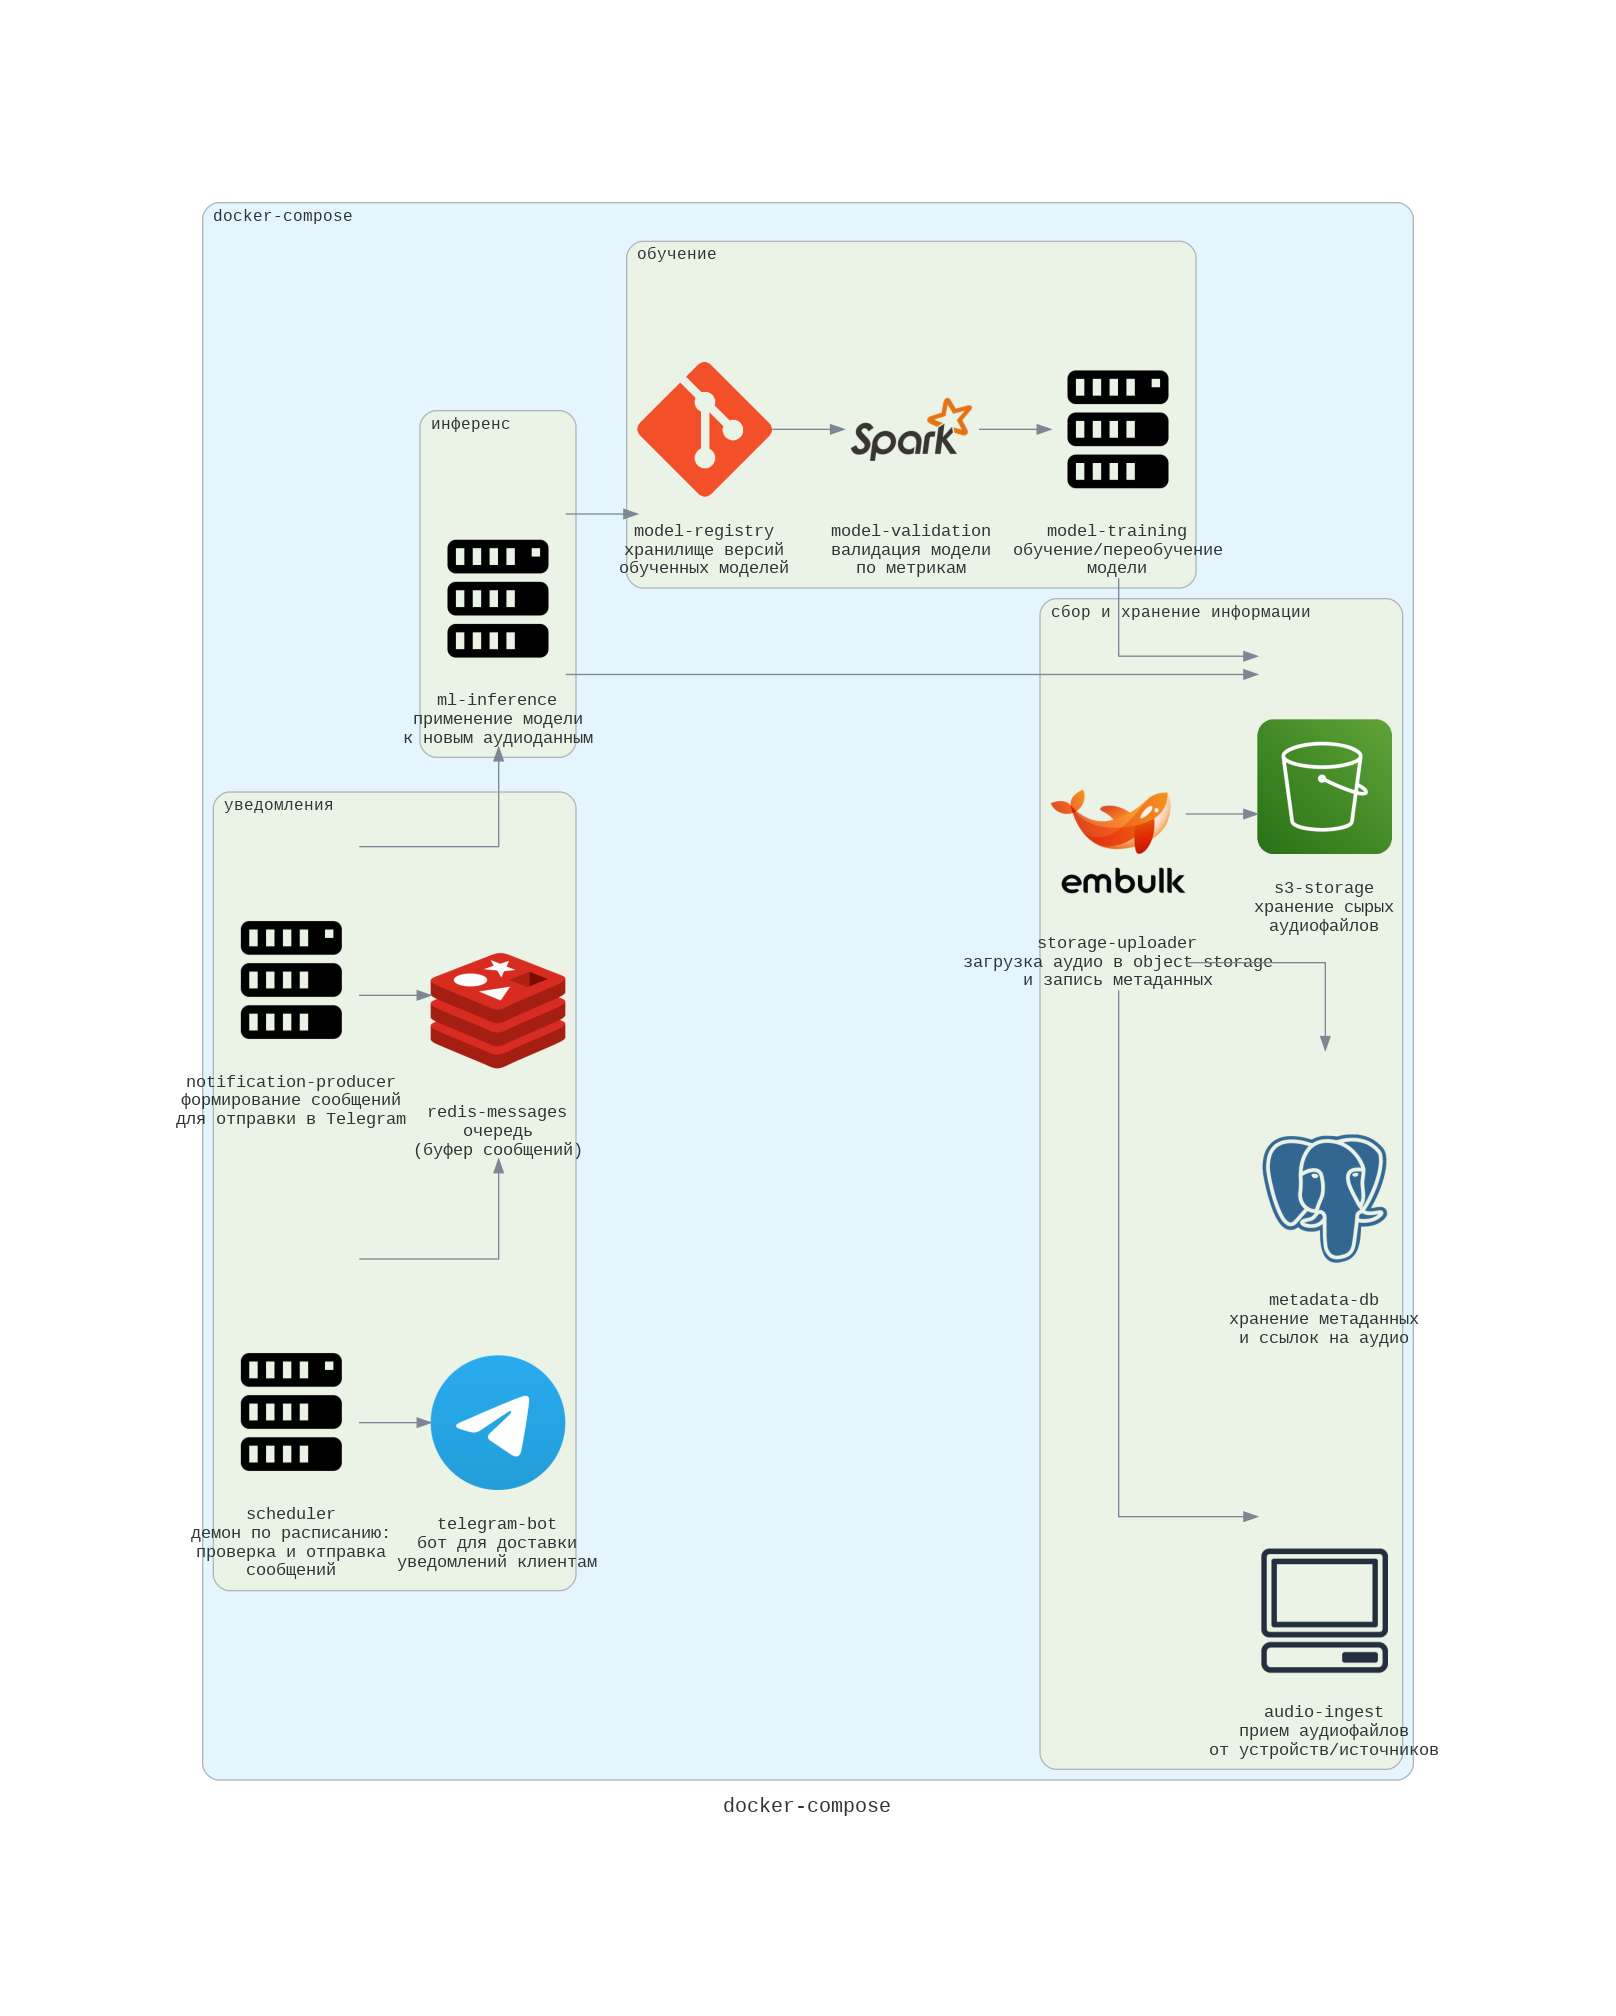

In [105]:
from IPython.display import Image, display
image_path = '/content/docker-compose.png'
display(Image(filename=image_path))